In [1]:
import numpy as np
from scipy.interpolate import interp2d
from scipy.io import mmread, mmwrite

import matplotlib
import matplotlib.pyplot as plt
#import matplotlib.pyplot as plt

from mpl_toolkits.axes_grid1 import ImageGrid

import mpmath as mp
from mpmath import *

from PIL import Image

#from scipy.spatial import KDTree
#from time import process_time

from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import ImageGrid

cmap=plt.get_cmap('RdBu')
class MidpointNormalize(Normalize):
    def __init__(self, vmin=None, vmax=None, midpoint=None, clip=False):
        self.midpoint = midpoint
        Normalize.__init__(self, vmin, vmax, clip)

    def __call__(self, value, clip=None):
        # I'm ignoring masked values and all kinds of edge cases to make a
        # simple example...
        x, y = [self.vmin, self.midpoint, self.vmax], [0, 0.5, 1]
        return np.ma.masked_array(np.interp(value, x, y))

norm = MidpointNormalize(midpoint=0)



In [2]:
def add_inner_title(ax, title, loc, **kwargs):
    from matplotlib.offsetbox import AnchoredText
    from matplotlib.patheffects import withStroke
    prop = dict(path_effects=[withStroke(foreground='w', linewidth=3)],
                size=plt.rcParams['legend.fontsize'])
    at = AnchoredText(title, loc=loc, prop=prop,
                      pad=0., borderpad=0.5,
                      frameon=False, **kwargs)
    ax.add_artist(at)
    return at

In [3]:
pdf_name_mzeta = "./zeta.pdf"
pdf_name_histN = "./histN.pdf"
pdf_name_histXi2pcf = "./histXi2pcf.pdf"


Output_dir = f"../Output/"
#Output_dir_vs = f"../Output_tree-omp-sincos_rsmooth/"
#Output_dir = f"../Outputs_to-test_rsmooth_ns1024/Output_tree-omp-sincos_no-one-ball_rsm09_no-Update-True/"
#Output_dir = f"../Outputs_to-test_rsmooth_ns1024/Output_tree-omp-sincos_no-one-ball_rsm09/"
#Output_dir = f"../Outputs_to-test_rsmooth_ns1024/Output_tree-omp-sincos_no-one-ball_rsm10_no-Update-True/"
#Output_dir_vs = f"../Outputs_to-test_rsmooth_ns1024/Output_tree-omp-sincos_no-one-ball_rsm10/"
#Output_dir = f"../Outputs_to-test_rsmooth_ns1024/Output_tree-omp-sincos_no-one-ball_rsm11_no-Update-True/"
#Output_dir_vs = f"../Outputs_to-test_rsmooth_ns1024/Output_tree-omp-sincos_no-one-ball_rsm11/"
#Output_dir = f"../Outputs_to-test_rsmooth_ns1024/Output_tree-omp-sincos/"
#Output_dir = f"../Outputs_to-test_rsmooth_ns1024/Output_tree-omp-sincos_no-one-ball/"
#Output_dir = f"../Output_balls-omp-sincos_09/"
#Output_dir = f"../Output_balls-omp-sincos_10/"
#Output_dir = f"../Output_balls-omp-sincos_11/"
#Output_dir = f"../Cosma/Takahasi_zs9_r000/Output_tree-omp-sincos_nres13r000_zs9_old-ranges/"
#Output_dir = f"../Cosma/Takahasi_zs9_r000/Output_balls-omp_nres12r000_zs9_old-ranges/"
#Output_dir = f"../Cosma/Takahasi_zs9_r000/Output_balls-omp_nres13r000_zs9_old-ranges/"
#
#Output_dir = f"../Cosma/Takahasi_zs9_r000/Output_balls-omp_nres13r000_zs9/"
#
#Output_dir = f"../Cosma/Takahasi_zs9_r000/Output_balls-omp_nres12r000_zs9_new/"
#Output_dir = f"../Cosma/Takahasi_zs9_r000/Output_balls-omp_nres12r000_zs9_rsmooth/"
#Output_dir = f"../Cosma/Takahasi_zs9_r000/Output_balls-omp_nres12r000_zs9_rsmooth_12/"
#Output_dir = f"../Cosma/Takahasi_zs9_r000/Output_balls-omp_nres12r000_zs9_rsmooth_13/"
#Output_dir = f"../Cosma/Takahasi_zs9_r000/Output_balls-omp_nres12r000_zs9_rsmooth_14/"
#Output_dir = f"../Cosma/Takahasi_zs9_r000/Output_balls-omp_nres12r000_zs9_rsmooth_15/"
#Output_dir = f"../Cosma/Takahasi_zs9_r000/Output_balls-omp_nres12r000_zs9_rsmooth_16/"
#Output_dir = f"../Cosma/Takahasi_zs9_r000/Output_balls-omp_nres12r000_zs9_rsmooth_17/"
#
#Output_dir = f"../Cosma/Takahasi_nres13/Output_balls-omp_nres13r000_zs9/"
#Output_dir = f"../Eladio/Output_nside512-1024_tree-omp-sincos_no-one-ball/"
#Output_dir = f"../Cosma/Output/"
#
#Output_dir = f"../Cosma/Output_balls-omp-sincos_nres12r000_zs9/"
#Output_dir = f"../Cosma/Output_tree-omp-sincos_nres12r000_zs9/"
#Output_dir_vs = f"../Cosma/Takahasi/zs9/r000/Output_tree-omp-sincos_nres12r000_zs9/"
#
#Output_dir_vs = f"../Eladio/Output_nside512_tree-omp-sincos/"
#Output_dir_vs = f"../Eladio/Output_nside512_tree-omp-sincos_no-one-ball/"
#Output_dir_vs = f"../Eladio/Output_nside512-1024_tree-omp-sincos_no-one-ball/"
#
Output_dir_vs = f"../Eladio/Output_nside1024_tree-omp-sincos/"
#Output_dir_vs = f"../Eladio/Output_nside1024_balls-omp-sincos/"
#Output_dir_vs = f"../Eladio/Output_nside1024_tree-omp-sincos_center-of-mass/"
#
#
#Output_dir_vs = f"../Eladio/Output_nside1024_tree-omp-sincos_no-one-ball/"
#
#
#Output_dir = f"../Cosma/Takahasi_nres12_balls-omp/zs9/r002/Output_balls-omp-sincos_nres12r002_zs9_arfken/"
#Output_dir_vs = f"../Cosma/Takahasi_nres12_balls-omp/zs9/r002/Output_balls-omp-sincos_nres12r002_zs9/"
#
#Output_dir_vs = f"../Cosma/Takahasi_nres12/zs9/r000/Output_tree-omp-sincos_nres12r000_zs9/"
#Output_dir_vs = f"../Cosma/Takahasi_nres12/zs9/r000/Output_tree-omp-sincos_nres13r000_zs9/"
#Output_dir_vs = f"../Cosma/Takahasi_nres13/Output_balls-omp_nres13r000_zs9_smooth-pivot/"
#Output_dir_vs = f"../Cosma/Takahasi_nres13/Output_balls-omp_nres13r000_zs9_smooth-pivot_2/"
#Output_dir_vs = f"../Eladio/Output_nside1024_balls-omp-sincos/"
#
#Output_dir_vs = f"../Cosma/Takahasi_zs9_r000/Output_tree-omp-sincos_nres12r000_zs9_old-ranges/"
#Output_dir_vs = f"../Cosma/Takahasi_zs9_r000/Output_tree-omp-sincos_nres13r000_zs9_old-ranges/"
#
#Output_dir_vs = f"../Cosma/Takahasi_zs9_r000/Output_balls-omp_nres12r000_zs9/"
#
# Tests Cosma rsmooth old ranges 
#
#Output_dir = f"../Cosma/Takahasi_nres12_test-rsmooth/Output_nres12r000_zs9_balls-omp_rsmooth/"
#Output_dir_vs = f"../Cosma/Takahasi_nres12_test-rsmooth/Output_nres12r000_zs9_balls-omp/"
#
#Output_dir = f"../Cosma/Takahasi_nres12_test-rsmooth/Output_nres12r000_zs9_tree-omp_rsmooth/"
#Output_dir_vs = f"../Cosma/Takahasi_nres12_test-rsmooth/Output_nres12r000_zs9_tree-omp/"
#
#Output_dir = f"../Cosma/Takahasi_nres12_test-rsmooth_normalized/Output_nres12r000_zs9_tree-omp_no-one-ball_rsmooth/"
#Output_dir = f"../Cosma/Takahasi_nres12_test-rsmooth_normalized/Output_nres12r000_zs9_tree-omp_no-one-ball_rsmooth_normalized/"
#Output_dir = f"../Cosma/Takahasi_nres12_test-rsmooth/Output_nres12r000_zs9_tree-omp_no-one-ball_rsmooth/"
#Output_dir = f"../Cosma/Takahasi_nres12_test-rsmooth/Output_nres12r000_zs9_tree-omp_no-one-ball_rsmooth_normalized/"
#Output_dir_vs = f"../Cosma/Takahasi_nres12_test-rsmooth/Output_nres12r000_zs9_tree-omp_no-one-ball/"
#
plots_dir = f"./"
extension = ".txt"

input1_cos_file = f"{Output_dir}histZetaM_cos_1{extension}"
input2_cos_file = f"{Output_dir}histZetaM_cos_2{extension}"
input3_cos_file = f"{Output_dir}histZetaM_cos_3{extension}"
input4_cos_file = f"{Output_dir}histZetaM_cos_4{extension}"
input5_cos_file = f"{Output_dir}histZetaM_cos_5{extension}"
input6_cos_file = f"{Output_dir}histZetaM_cos_6{extension}"
input7_cos_file = f"{Output_dir}histZetaM_cos_7{extension}"
input8_cos_file = f"{Output_dir}histZetaM_cos_8{extension}"
input9_cos_file = f"{Output_dir}histZetaM_cos_9{extension}"

histNFile_file = f"{Output_dir}histN{extension}"
histCFFile_file = f"{Output_dir}histCF{extension}"
histXi2pcfFile_file = f"{Output_dir}histXi2pcf{extension}"

ycolumn=3

In [4]:
input1=np.loadtxt(input1_cos_file)
input2=np.loadtxt(input2_cos_file)
input3=np.loadtxt(input3_cos_file)
input4=np.loadtxt(input4_cos_file)
input5=np.loadtxt(input5_cos_file)
input6=np.loadtxt(input6_cos_file)
input7=np.loadtxt(input7_cos_file)
input8=np.loadtxt(input8_cos_file)
input9=np.loadtxt(input9_cos_file)


In [5]:
xd1 = input1[:,0]
yd1 = input1[:,1]
yd2 = input2[:,1]
yd3 = input3[:,1]
yd4 = input4[:,1]
yd5 = input5[:,1]
#yd2 = input1[:,2]
#yd3 = input1[:,3]
#yd4 = input1[:,4]
#yd5 = input1[:,5]


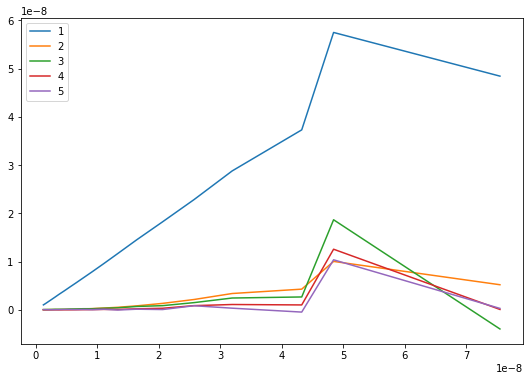

In [6]:
fig1 = plt.figure(figsize=(9,6))
plt.plot(xd1, yd1, label="1")
plt.plot(xd1, yd2, label="2")
plt.plot(xd1, yd3, label="3")
plt.plot(xd1, yd4, label="4")
plt.plot(xd1, yd5, label="5")
plt.legend()
#plt.xlim(1, 10)
#plt.ylim(0, 50)
fig1.savefig(pdf_name_mzeta)

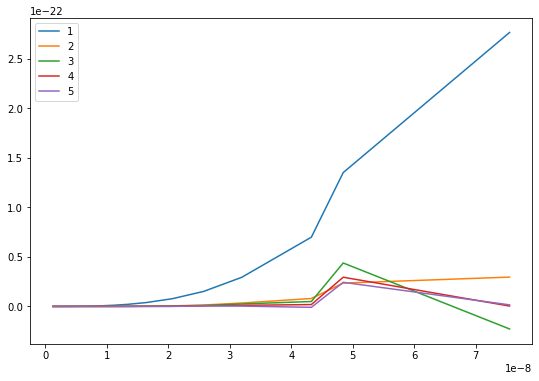

In [7]:
fig1 = plt.figure(figsize=(9,6))
plt.plot(xd1, xd1*xd1*yd1, label="1")
plt.plot(xd1, xd1*xd1*yd2, label="2")
plt.plot(xd1, xd1*xd1*yd3, label="3")
plt.plot(xd1, xd1*xd1*yd4, label="4")
plt.plot(xd1, xd1*xd1*yd5, label="5")
plt.legend()
#plt.xlim(1, 10)
#plt.ylim(0, 50)
fig1.savefig(pdf_name_mzeta)

20
20


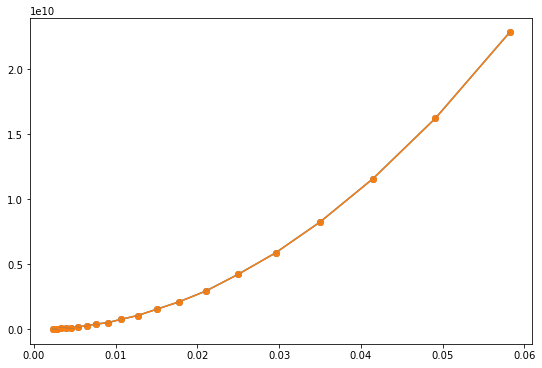

In [8]:
histNFile=np.loadtxt(histNFile_file)
NdataHistN = np.shape(histNFile)[0]
print(NdataHistN)
xd=histNFile[:,0]
yd=histNFile[:,1]
#
input_file_vs = f"{Output_dir_vs}histN{extension}"
histNFile1=np.loadtxt(input_file_vs)
NdataHistN1 = np.shape(histNFile1)[0]
print(NdataHistN1)
xd1=histNFile1[:,0]
yd1=histNFile1[:,1]
fig6 = plt.figure(figsize=(9,6))
plt.plot(xd,yd)
plt.scatter(xd,yd)
plt.plot(xd1,yd1)
plt.scatter(xd1,yd1)
#plt.scatter(xd,yd)
#plt.plot(xd,xd*yd)
#plt.xscale("log")
#plt.yscale("log")
#plt.xlim(20, 100)
#plt.ylim(-1, 1)
#plt.xlim(0, 20)
#plt.ylim(0, 10)
plt.show()
fig6.savefig(pdf_name_histN)

20
20


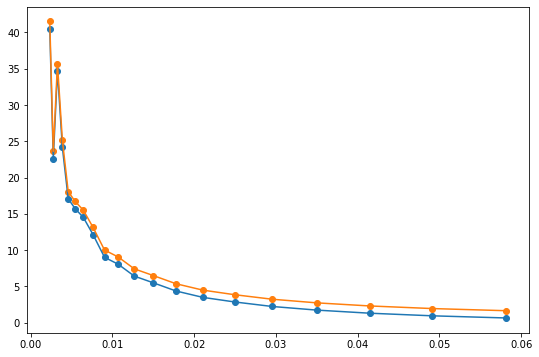

In [9]:
histCFFile=np.loadtxt(histCFFile_file)
NdataHistCF = np.shape(histCFFile)[0]
print(NdataHistCF)
xd=histCFFile[:,0]
yd=histCFFile[:,1]
input_file_vs = f"{Output_dir_vs}histCF{extension}"
histNFile1=np.loadtxt(input_file_vs)
NdataHistN1 = np.shape(histNFile1)[0]
print(NdataHistN1)
xd1=histNFile1[:,0]
yd1=histNFile1[:,1]
fig6 = plt.figure(figsize=(9,6))
plt.plot(xd,yd)
plt.scatter(xd,yd)
plt.plot(xd1,yd1)
plt.scatter(xd1,yd1)
plt.show()
fig6.savefig(pdf_name_histN)

20
20


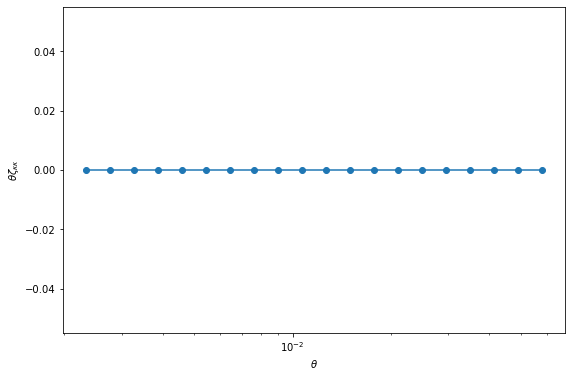

In [10]:
histNFile=np.loadtxt(histXi2pcfFile_file)
NdataHistN = np.shape(histNFile)[0]
print(NdataHistN)
xd=histNFile[:,0]
yd=histNFile[:,1]
input_file_vs = f"{Output_dir_vs}histXi2pcf{extension}"
histNFile1=np.loadtxt(input_file_vs)
NdataHistN1 = np.shape(histNFile1)[0]
print(NdataHistN1)
xd1=histNFile1[:,0]
yd1=histNFile1[:,1]
#fac=180*60
fac=180*60/np.pi
#fac=4*180*60/np.pi
fig7 = plt.figure(figsize=(9,6))
#
#plt.plot(xd,yd)
#plt.scatter(xd,yd)
#plt.plot(xd1,yd1)
#plt.scatter(xd1,yd1)
#
plt.plot(xd1,100*(yd1-yd)/yd1)
plt.scatter(xd1,100*(yd1-yd)/yd1)
#
#plt.plot(xd,xd*yd)
#plt.scatter(xd,xd*yd)
#
#plt.scatter(xd*fac,xd*(fac)*yd)
#plt.plot(xd*fac,xd*(fac)*yd)
#plt.scatter(xd1*fac,xd1*(fac)*yd)
#plt.plot(xd1*fac,xd1*(fac)*yd)
#
plt.xscale("log")
#plt.yscale("log")
#plt.xlim(5, 100)
#plt.ylim(0, 2.0E-5)
#plt.ylim(1.0e-7, 2.0e-3)
plt.xlabel("$\\theta$")
plt.ylabel("$\\theta \zeta_{\kappa\kappa}$");
plt.show()
fig7.savefig(pdf_name_histXi2pcf)

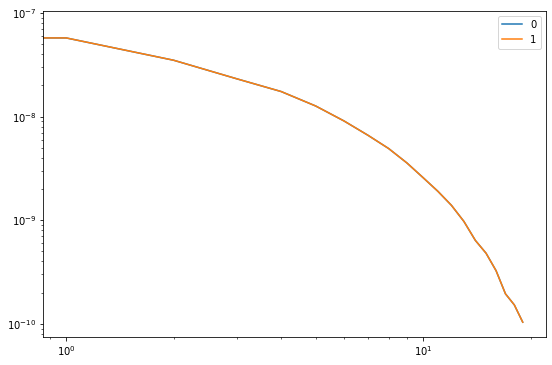

In [11]:
pdf_name_diagonal = "./mZeta_diagonal.pdf"
input1_file = f"{Output_dir}histZetaM_cos_1{extension}"
input1=np.loadtxt(input1_file)
input_file_vs = f"{Output_dir_vs}histZetaM_cos_1{extension}"
input2=np.loadtxt(input_file_vs)
fig5 = plt.figure(figsize=(9,6))
plt.plot(np.diag(input1), label="0")
plt.plot(np.diag(input2), label="1")
plt.legend()
#plt.xlim(1, 10)
#plt.ylim(0, 100)
plt.xscale("log")
plt.yscale("log")
fig5.savefig(pdf_name_diagonal)

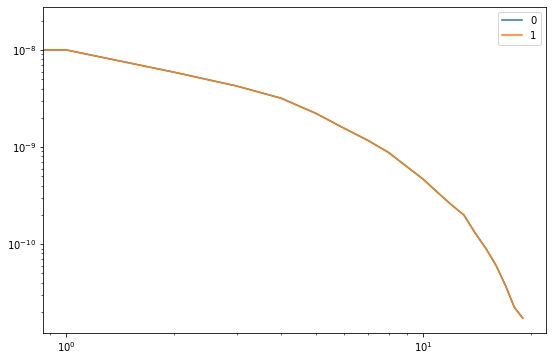

In [12]:
pdf_name_diagonal = "./mZeta_diagonal.pdf"
input1_file = f"{Output_dir}histZetaM_cos_2{extension}"
input1=np.loadtxt(input1_file)
input_file_vs = f"{Output_dir_vs}histZetaM_cos_2{extension}"
input2=np.loadtxt(input_file_vs)
fig5 = plt.figure(figsize=(9,6))
plt.plot(np.diag(input1), label="0")
plt.plot(np.diag(input2), label="1")
plt.legend()
#plt.xlim(1, 10)
#plt.ylim(0, 100)
plt.xscale("log")
plt.yscale("log")
fig5.savefig(pdf_name_diagonal)

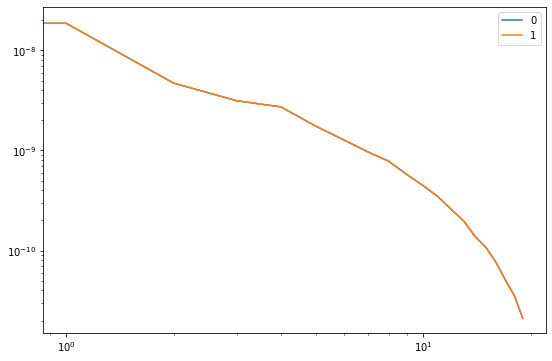

In [13]:
pdf_name_diagonal = "./mZeta_diagonal.pdf"
input1_file = f"{Output_dir}histZetaM_cos_3{extension}"
input1=np.loadtxt(input1_file)
input_file_vs = f"{Output_dir_vs}histZetaM_cos_3{extension}"
input2=np.loadtxt(input_file_vs)
fig5 = plt.figure(figsize=(9,6))
plt.plot(np.diag(input1), label="0")
plt.plot(np.diag(input2), label="1")
plt.legend()
#plt.xlim(1, 10)
#plt.ylim(0, 100)
plt.xscale("log")
plt.yscale("log")
fig5.savefig(pdf_name_diagonal)

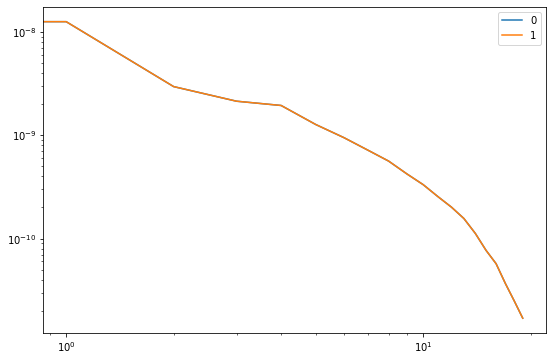

In [14]:
pdf_name_diagonal = "./mZeta_diagonal.pdf"
input1_file = f"{Output_dir}histZetaM_cos_4{extension}"
input1=np.loadtxt(input1_file)
input_file_vs = f"{Output_dir_vs}histZetaM_cos_4{extension}"
input2=np.loadtxt(input_file_vs)
fig5 = plt.figure(figsize=(9,6))
plt.plot(np.diag(input1), label="0")
plt.plot(np.diag(input2), label="1")
plt.legend()
#plt.xlim(1, 10)
#plt.ylim(0, 100)
plt.xscale("log")
plt.yscale("log")
fig5.savefig(pdf_name_diagonal)

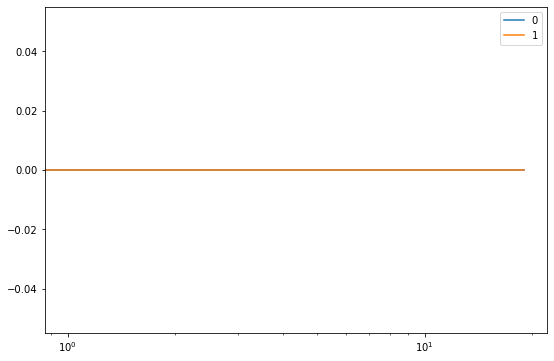

In [15]:
pdf_name_diagonal = "./mZeta_diagonal.pdf"
input1_file = f"{Output_dir}histZetaM_sin_1{extension}"
input1=np.loadtxt(input1_file)
input_file_vs = f"{Output_dir_vs}histZetaM_sin_1{extension}"
input2=np.loadtxt(input_file_vs)
fig5 = plt.figure(figsize=(9,6))
plt.plot(np.diag(input1), label="0")
plt.plot(np.diag(input2), label="1")
plt.legend()
#plt.xlim(1, 10)
#plt.ylim(0, 100)
plt.xscale("log")
#plt.yscale("log")
fig5.savefig(pdf_name_diagonal)

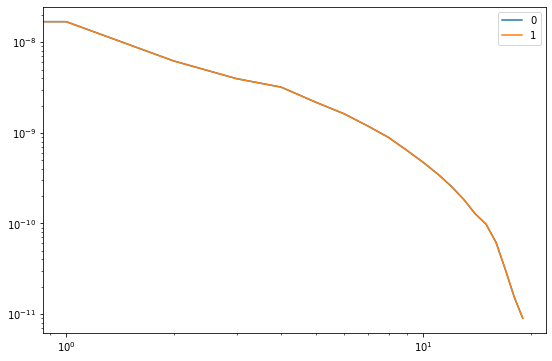

In [16]:
pdf_name_diagonal = "./mZeta_diagonal.pdf"
input1_file = f"{Output_dir}histZetaM_sin_2{extension}"
input1=np.loadtxt(input1_file)
input_file_vs = f"{Output_dir_vs}histZetaM_sin_2{extension}"
input2=np.loadtxt(input_file_vs)
fig5 = plt.figure(figsize=(9,6))
plt.plot(np.diag(input1), label="0")
plt.plot(np.diag(input2), label="1")
plt.legend()
#plt.xlim(1, 10)
#plt.ylim(0, 100)
plt.xscale("log")
plt.yscale("log")
fig5.savefig(pdf_name_diagonal)

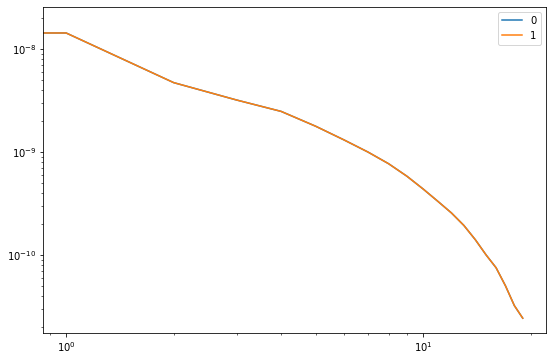

In [17]:
pdf_name_diagonal = "./mZeta_diagonal.pdf"
input1_file = f"{Output_dir}histZetaM_sin_3{extension}"
input1=np.loadtxt(input1_file)
input_file_vs = f"{Output_dir_vs}histZetaM_sin_3{extension}"
input2=np.loadtxt(input_file_vs)
fig5 = plt.figure(figsize=(9,6))
plt.plot(np.diag(input1), label="0")
plt.plot(np.diag(input2), label="1")
plt.legend()
#plt.xlim(1, 10)
#plt.ylim(0, 100)
plt.xscale("log")
plt.yscale("log")
fig5.savefig(pdf_name_diagonal)

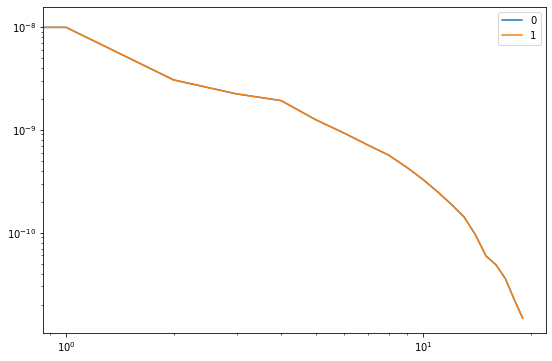

In [18]:
pdf_name_diagonal = "./mZeta_diagonal.pdf"
input1_file = f"{Output_dir}histZetaM_sin_4{extension}"
input1=np.loadtxt(input1_file)
input_file_vs = f"{Output_dir_vs}histZetaM_sin_4{extension}"
input2=np.loadtxt(input_file_vs)
fig5 = plt.figure(figsize=(9,6))
plt.plot(np.diag(input1), label="0")
plt.plot(np.diag(input2), label="1")
plt.legend()
#plt.xlim(1, 10)
#plt.ylim(0, 100)
plt.xscale("log")
plt.yscale("log")
fig5.savefig(pdf_name_diagonal)

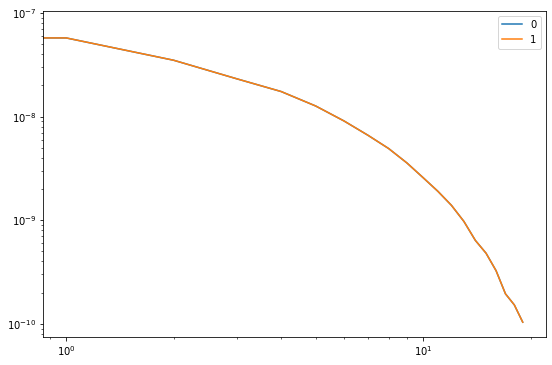

In [19]:
pdf_name_diagonal = "./mZeta_diagonal.pdf"
input1_file_cos = f"{Output_dir}histZetaM_cos_1{extension}"
input1_file_sin = f"{Output_dir}histZetaM_sin_1{extension}"
input1_cos=np.loadtxt(input1_file_cos)
input1_sin=np.loadtxt(input1_file_sin)
input1 = input1_cos + input1_sin
input_file_vs_2_cos = f"{Output_dir_vs}histZetaM_cos_1{extension}"
input_file_vs_2_sin = f"{Output_dir_vs}histZetaM_sin_1{extension}"
input2_cos=np.loadtxt(input_file_vs_2_cos)
input2_sin=np.loadtxt(input_file_vs_2_sin)
input2 = input2_cos + input2_sin
fig5 = plt.figure(figsize=(9,6))
plt.plot(np.diag(input1), label="0")
plt.plot(np.diag(input2), label="1")
plt.legend()
plt.xscale("log")
plt.yscale("log")
fig5.savefig(pdf_name_diagonal)

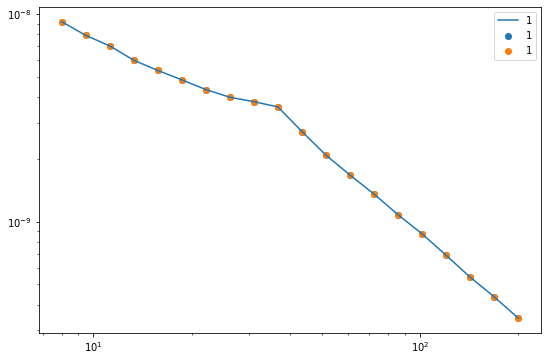

In [20]:
input1_file = f"{Output_dir}mhistZeta_cos_1{extension}"
input1=np.loadtxt(input1_file)
xd1 = input1[:,0]
yd1 = input1[:,ycolumn]
input_file_vs = f"{Output_dir_vs}mhistZeta_cos_1{extension}"
input2=np.loadtxt(input_file_vs)
xd2 = input2[:,0]
yd2 = input2[:,ycolumn]
#
fac=180*60/np.pi
#
fig1 = plt.figure(figsize=(9,6))
#
plt.plot(xd1*fac, yd1, label="1")
plt.scatter(xd1*fac, yd1, label="1")
#plt.plot(xd2*fac, yd2, label="1")
plt.scatter(xd2*fac, yd2, label="1")
#
plt.xscale("log")
plt.yscale("log")
plt.legend()
fig1.savefig(pdf_name_mzeta)

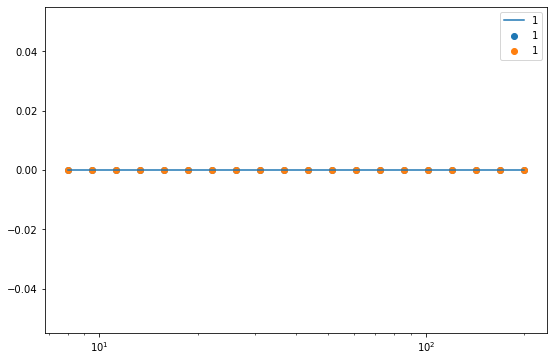

In [21]:
input1_file = f"{Output_dir}mhistZeta_sin_1{extension}"
input1=np.loadtxt(input1_file)
xd1 = input1[:,0]
yd1 = input1[:,ycolumn]
input_file_vs = f"{Output_dir_vs}mhistZeta_sin_1{extension}"
input2=np.loadtxt(input_file_vs)
xd2 = input2[:,0]
yd2 = input2[:,ycolumn]
#
fac=180*60/np.pi
#
fig1 = plt.figure(figsize=(9,6))
#
plt.plot(xd1*fac, yd1, label="1")
plt.scatter(xd1*fac, yd1, label="1")
#plt.plot(xd2*fac, yd2, label="1")
plt.scatter(xd2*fac, yd2, label="1")
#
plt.xscale("log")
#plt.yscale("log")
plt.legend()
fig1.savefig(pdf_name_mzeta)

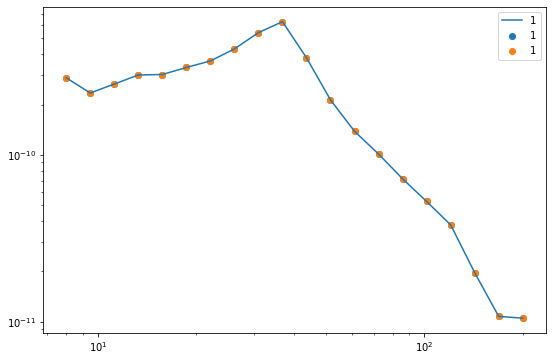

In [22]:
input1_file = f"{Output_dir}mhistZeta_cos_2{extension}"
input1=np.loadtxt(input1_file)
xd1 = input1[:,0]
yd1 = input1[:,ycolumn]
input_file_vs = f"{Output_dir_vs}mhistZeta_cos_2{extension}"
input2=np.loadtxt(input_file_vs)
xd2 = input2[:,0]
yd2 = input2[:,ycolumn]
#
fac=180*60/np.pi
#
fig1 = plt.figure(figsize=(9,6))
#
plt.plot(xd1*fac, yd1, label="1")
plt.scatter(xd1*fac, yd1, label="1")
#plt.plot(xd2*fac, yd2, label="1")
plt.scatter(xd2*fac, yd2, label="1")
#
plt.xscale("log")
plt.yscale("log")
plt.legend()
fig1.savefig(pdf_name_mzeta)

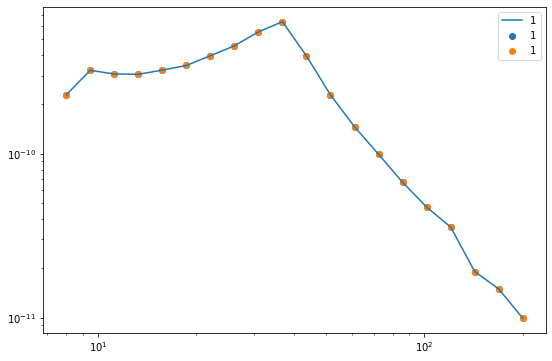

In [23]:
input1_file = f"{Output_dir}mhistZeta_sin_2{extension}"
input1=np.loadtxt(input1_file)
xd1 = input1[:,0]
yd1 = input1[:,ycolumn]
input_file_vs = f"{Output_dir_vs}mhistZeta_sin_2{extension}"
input2=np.loadtxt(input_file_vs)
xd2 = input2[:,0]
yd2 = input2[:,ycolumn]
#
fac=180*60/np.pi
#
fig1 = plt.figure(figsize=(9,6))
#
plt.plot(xd1*fac, yd1, label="1")
plt.scatter(xd1*fac, yd1, label="1")
#plt.plot(xd2*fac, yd2, label="1")
plt.scatter(xd2*fac, yd2, label="1")
#
plt.xscale("log")
plt.yscale("log")
plt.legend()
fig1.savefig(pdf_name_mzeta)

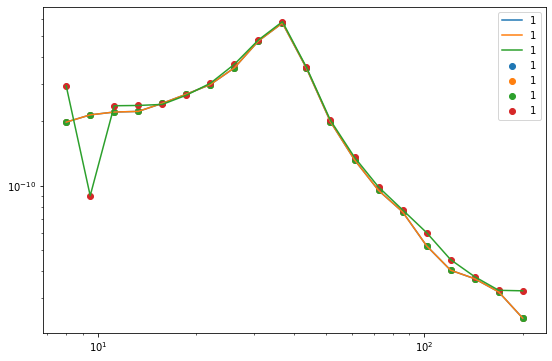

In [24]:
input1_file = f"{Output_dir}mhistZeta_cos_3{extension}"
input1=np.loadtxt(input1_file)
xd1 = input1[:,0]
yd1 = input1[:,ycolumn]
input_file_vs_2 = f"{Output_dir_vs}mhistZeta_cos_3{extension}"
input2=np.loadtxt(input_file_vs_2)
xd2 = input2[:,0]
yd2 = input2[:,ycolumn]
#
input3_file = f"{Output_dir}mhistZeta_sin_3{extension}"
input3=np.loadtxt(input1_file)
xd3 = input3[:,0]
yd3 = input3[:,ycolumn]
input_file_vs_4 = f"{Output_dir_vs}mhistZeta_sin_3{extension}"
input4=np.loadtxt(input_file_vs_4)
xd4 = input4[:,0]
yd4 = input4[:,ycolumn]
#
fac=180*60/np.pi
#
fig1 = plt.figure(figsize=(9,6))
#
plt.plot(xd1*fac, yd1, label="1")
plt.scatter(xd1*fac, yd1, label="1")
#plt.plot(xd2*fac, yd2, label="1")
plt.scatter(xd2*fac, yd2, label="1")
#
plt.plot(xd3*fac, yd3, label="1")
plt.scatter(xd3*fac, yd3, label="1")
plt.plot(xd4*fac, yd4, label="1")
plt.scatter(xd4*fac, yd4, label="1")
#
plt.xscale("log")
plt.yscale("log")
plt.legend()
fig1.savefig(pdf_name_mzeta)

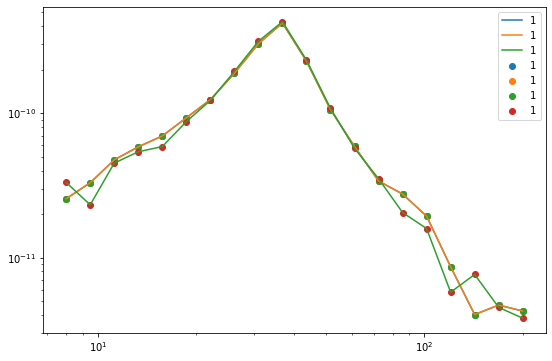

In [25]:
input1_file = f"{Output_dir}mhistZeta_cos_4{extension}"
input1=np.loadtxt(input1_file)
xd1 = input1[:,0]
yd1 = input1[:,ycolumn]
input_file_vs_2 = f"{Output_dir_vs}mhistZeta_cos_4{extension}"
input2=np.loadtxt(input_file_vs_2)
xd2 = input2[:,0]
yd2 = input2[:,ycolumn]
#
input3_file = f"{Output_dir}mhistZeta_sin_4{extension}"
input3=np.loadtxt(input1_file)
xd3 = input3[:,0]
yd3 = input3[:,ycolumn]
input_file_vs_4 = f"{Output_dir_vs}mhistZeta_sin_4{extension}"
input4=np.loadtxt(input_file_vs_4)
xd4 = input4[:,0]
yd4 = input4[:,ycolumn]
#
fac=180*60/np.pi
#
fig1 = plt.figure(figsize=(9,6))
#
plt.plot(xd1*fac, yd1, label="1")
plt.scatter(xd1*fac, yd1, label="1")
#plt.plot(xd2*fac, yd2, label="1")
plt.scatter(xd2*fac, yd2, label="1")
#
plt.plot(xd3*fac, yd3, label="1")
plt.scatter(xd3*fac, yd3, label="1")
plt.plot(xd4*fac, yd4, label="1")
plt.scatter(xd4*fac, yd4, label="1")
#
plt.xscale("log")
plt.yscale("log")
plt.legend()
fig1.savefig(pdf_name_mzeta)

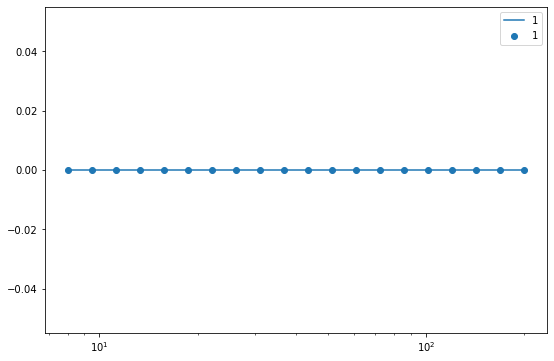

In [26]:
input1_file = f"{Output_dir}mhistZeta_cos_1{extension}"
input1=np.loadtxt(input1_file)
input2_file = f"{Output_dir}mhistZeta_sin_1{extension}"
input2=np.loadtxt(input2_file)
xd1 = input1[:,0]
yd1 = input1[:,ycolumn]+input2[:,ycolumn]
input_file_vs_1 = f"{Output_dir_vs}mhistZeta_cos_1{extension}"
input_file_vs_2 = f"{Output_dir_vs}mhistZeta_sin_1{extension}"
input1=np.loadtxt(input_file_vs_1)
input2=np.loadtxt(input_file_vs_2)
xd2 = input2[:,0]
yd2 = input1[:,ycolumn]+input2[:,ycolumn]
#
fac=180*60/np.pi
#
fig1 = plt.figure(figsize=(9,6))
#
plt.plot(xd1*fac, 100*(yd2-yd1)/yd2, label="1")
plt.scatter(xd1*fac, 100*(yd2-yd1)/yd2, label="1")
#
plt.xscale("log")
plt.legend()
fig1.savefig(pdf_name_mzeta)

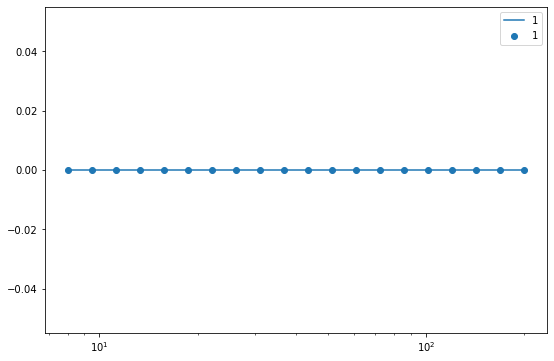

In [27]:
input1_file = f"{Output_dir}mhistZeta_cos_2{extension}"
input1=np.loadtxt(input1_file)
input2_file = f"{Output_dir}mhistZeta_sin_2{extension}"
input2=np.loadtxt(input2_file)
xd1 = input1[:,0]
yd1 = input1[:,ycolumn]+input2[:,ycolumn]
input_file_vs_1 = f"{Output_dir_vs}mhistZeta_cos_2{extension}"
input_file_vs_2 = f"{Output_dir_vs}mhistZeta_sin_2{extension}"
input1=np.loadtxt(input_file_vs_1)
input2=np.loadtxt(input_file_vs_2)
xd2 = input2[:,0]
yd2 = input1[:,ycolumn]+input2[:,ycolumn]
#
fac=180*60/np.pi
#
fig1 = plt.figure(figsize=(9,6))
#
plt.plot(xd1*fac, 100*(yd2-yd1)/yd2, label="1")
plt.scatter(xd1*fac, 100*(yd2-yd1)/yd2, label="1")
#
plt.xscale("log")
plt.legend()
fig1.savefig(pdf_name_mzeta)

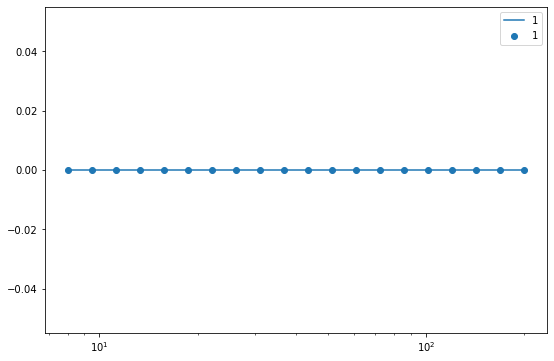

In [28]:
input1_file = f"{Output_dir}mhistZeta_cos_3{extension}"
input1=np.loadtxt(input1_file)
input2_file = f"{Output_dir}mhistZeta_sin_3{extension}"
input2=np.loadtxt(input2_file)
xd1 = input1[:,0]
yd1 = input1[:,ycolumn]+input2[:,ycolumn]
input_file_vs_1 = f"{Output_dir_vs}mhistZeta_cos_3{extension}"
input_file_vs_2 = f"{Output_dir_vs}mhistZeta_sin_3{extension}"
input1=np.loadtxt(input_file_vs_1)
input2=np.loadtxt(input_file_vs_2)
xd2 = input2[:,0]
yd2 = input1[:,ycolumn]+input2[:,ycolumn]
#
fac=180*60/np.pi
#
fig1 = plt.figure(figsize=(9,6))
#
plt.plot(xd1*fac, 100*(yd2-yd1)/yd2, label="1")
plt.scatter(xd1*fac, 100*(yd2-yd1)/yd2, label="1")
#
plt.xscale("log")
plt.legend()
fig1.savefig(pdf_name_mzeta)

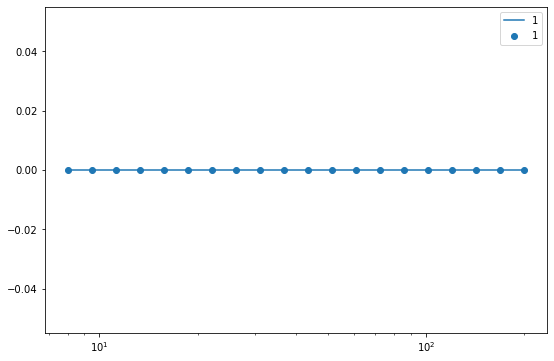

In [29]:
input1_file = f"{Output_dir}mhistZeta_cos_4{extension}"
input1=np.loadtxt(input1_file)
input2_file = f"{Output_dir}mhistZeta_sin_4{extension}"
input2=np.loadtxt(input2_file)
xd1 = input1[:,0]
yd1 = input1[:,ycolumn]+input2[:,ycolumn]
input_file_vs_1 = f"{Output_dir_vs}mhistZeta_cos_4{extension}"
input_file_vs_2 = f"{Output_dir_vs}mhistZeta_sin_4{extension}"
input1=np.loadtxt(input_file_vs_1)
input2=np.loadtxt(input_file_vs_2)
xd2 = input2[:,0]
yd2 = input1[:,ycolumn]+input2[:,ycolumn]
#
fac=180*60/np.pi
#
fig1 = plt.figure(figsize=(9,6))
#
plt.plot(xd1*fac, 100*(yd2-yd1)/yd2, label="1")
plt.scatter(xd1*fac, 100*(yd2-yd1)/yd2, label="1")
#
plt.xscale("log")
plt.legend()
fig1.savefig(pdf_name_mzeta)

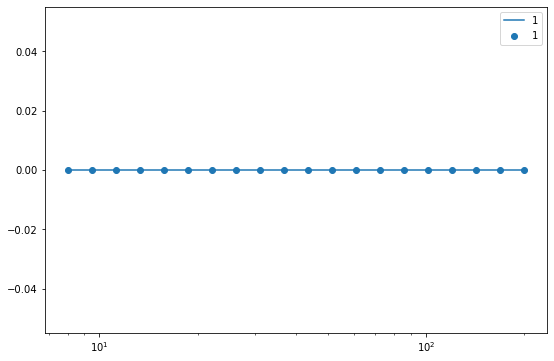

In [30]:
input1_file = f"{Output_dir}mhistZeta_cos_5{extension}"
input1=np.loadtxt(input1_file)
input2_file = f"{Output_dir}mhistZeta_sin_5{extension}"
input2=np.loadtxt(input2_file)
xd1 = input1[:,0]
yd1 = input1[:,ycolumn]+input2[:,ycolumn]
input_file_vs_1 = f"{Output_dir_vs}mhistZeta_cos_5{extension}"
input_file_vs_2 = f"{Output_dir_vs}mhistZeta_sin_5{extension}"
input1=np.loadtxt(input_file_vs_1)
input2=np.loadtxt(input_file_vs_2)
xd2 = input2[:,0]
yd2 = input1[:,ycolumn]+input2[:,ycolumn]
#
fac=180*60/np.pi
#
fig1 = plt.figure(figsize=(9,6))
#
plt.plot(xd1*fac, 100*(yd2-yd1)/yd2, label="1")
plt.scatter(xd1*fac, 100*(yd2-yd1)/yd2, label="1")
#
plt.xscale("log")
plt.legend()
fig1.savefig(pdf_name_mzeta)

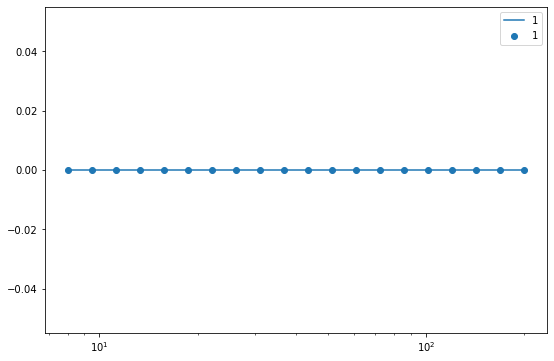

In [31]:
input1_file = f"{Output_dir}mhistZeta_cos_6{extension}"
input1=np.loadtxt(input1_file)
input2_file = f"{Output_dir}mhistZeta_sin_6{extension}"
input2=np.loadtxt(input2_file)
xd1 = input1[:,0]
yd1 = input1[:,ycolumn]+input2[:,ycolumn]
input_file_vs_1 = f"{Output_dir_vs}mhistZeta_cos_6{extension}"
input_file_vs_2 = f"{Output_dir_vs}mhistZeta_sin_6{extension}"
input1=np.loadtxt(input_file_vs_1)
input2=np.loadtxt(input_file_vs_2)
xd2 = input2[:,0]
yd2 = input1[:,ycolumn]+input2[:,ycolumn]
#
fac=180*60/np.pi
#
fig1 = plt.figure(figsize=(9,6))
#
plt.plot(xd1*fac, 100*(yd2-yd1)/yd2, label="1")
plt.scatter(xd1*fac, 100*(yd2-yd1)/yd2, label="1")
#
plt.xscale("log")
plt.legend()
fig1.savefig(pdf_name_mzeta)

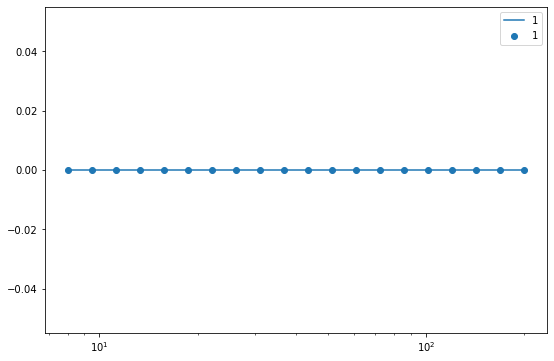

In [32]:
input1_file = f"{Output_dir}mhistZeta_cos_7{extension}"
input1=np.loadtxt(input1_file)
input2_file = f"{Output_dir}mhistZeta_sin_7{extension}"
input2=np.loadtxt(input2_file)
xd1 = input1[:,0]
yd1 = input1[:,3]+input2[:,3]
input_file_vs_1 = f"{Output_dir_vs}mhistZeta_cos_7{extension}"
input_file_vs_2 = f"{Output_dir_vs}mhistZeta_sin_7{extension}"
input1=np.loadtxt(input_file_vs_1)
input2=np.loadtxt(input_file_vs_2)
xd2 = input2[:,0]
yd2 = input1[:,3]+input2[:,3]
#
fac=180*60/np.pi
#
fig1 = plt.figure(figsize=(9,6))
#
plt.plot(xd1*fac, 100*(yd2-yd1)/yd2, label="1")
plt.scatter(xd1*fac, 100*(yd2-yd1)/yd2, label="1")
#
plt.xscale("log")
plt.legend()
fig1.savefig(pdf_name_mzeta)

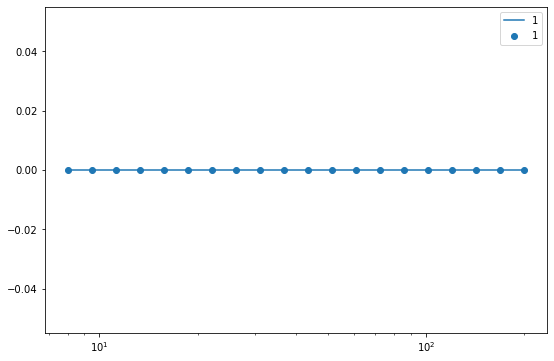

In [33]:
input1_file = f"{Output_dir}mhistZeta_cos_8{extension}"
input1=np.loadtxt(input1_file)
input2_file = f"{Output_dir}mhistZeta_sin_8{extension}"
input2=np.loadtxt(input2_file)
xd1 = input1[:,0]
yd1 = input1[:,ycolumn]+input2[:,ycolumn]
input_file_vs_1 = f"{Output_dir_vs}mhistZeta_cos_8{extension}"
input_file_vs_2 = f"{Output_dir_vs}mhistZeta_sin_8{extension}"
input1=np.loadtxt(input_file_vs_1)
input2=np.loadtxt(input_file_vs_2)
xd2 = input2[:,0]
yd2 = input1[:,ycolumn]+input2[:,ycolumn]
#
fac=180*60/np.pi
#
fig1 = plt.figure(figsize=(9,6))
#
plt.plot(xd1*fac, 100*(yd2-yd1)/yd2, label="1")
plt.scatter(xd1*fac, 100*(yd2-yd1)/yd2, label="1")
#
plt.xscale("log")
plt.legend()
fig1.savefig(pdf_name_mzeta)

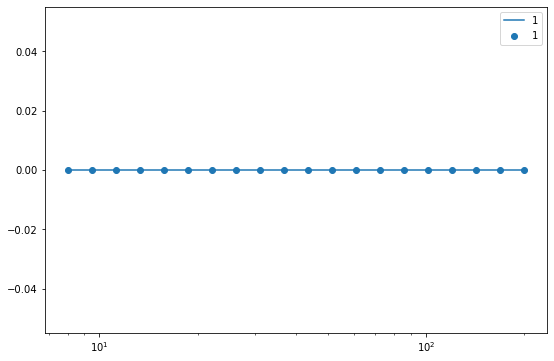

In [34]:
input1_file = f"{Output_dir}mhistZeta_cos_9{extension}"
input1=np.loadtxt(input1_file)
input2_file = f"{Output_dir}mhistZeta_sin_9{extension}"
input2=np.loadtxt(input2_file)
xd1 = input1[:,0]
yd1 = input1[:,ycolumn]+input2[:,ycolumn]
input_file_vs_1 = f"{Output_dir_vs}mhistZeta_cos_9{extension}"
input_file_vs_2 = f"{Output_dir_vs}mhistZeta_sin_9{extension}"
input1=np.loadtxt(input_file_vs_1)
input2=np.loadtxt(input_file_vs_2)
xd2 = input2[:,0]
yd2 = input1[:,ycolumn]+input2[:,ycolumn]
#
fac=180*60/np.pi
#
fig1 = plt.figure(figsize=(9,6))
#
#plt.plot(xd1*fac, yd1, label="1")
#plt.scatter(xd2*fac, yd2, label="1")
plt.plot(xd1*fac, 100*(yd2-yd1)/yd2, label="1")
plt.scatter(xd1*fac, 100*(yd2-yd1)/yd2, label="1")
#
plt.xscale("log")
#plt.yscale("log")
plt.legend()
fig1.savefig(pdf_name_mzeta)